In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') 

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2020, 2030, 2040, 2050] #, 2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

#### read in all AGWP[CO2/CH4/N2O], under fixed_AGWPCO2 approach, a future CO2 itself no longer has GWP=1 

In [3]:
ghggass = ['CO2', 'CH4', 'N2O']

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start2000MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

##### read fixed AGWP[CO2,2019] value

In [4]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101
agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### AGWP[future CO2/CH4/N2O] / AGWP[2019 CO2] 

In [5]:
# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

In [6]:
gwp_results['CO2']['ssp119']['2030']

array([1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474

In [7]:
gwp_results['CH4']['ssp119']['2050']

array([140.42733201, 138.90774667, 137.10040182, 135.07028031,
       132.86053947, 130.50021404, 128.03639691, 125.50923231,
       122.93016462, 120.33720447, 117.69317028, 115.06697242,
       112.4676378 , 109.90619873, 107.37407332, 104.91692337,
       102.51833756, 100.15749177,  97.85902552,  95.62752849,
        93.4610715 ,  91.36086917,  89.32665299,  87.36786265,
        85.46460058,  83.62353372,  81.84394945,  80.12422087,
        78.46178689,  76.85734136,  75.30655139,  73.80838944,
        72.36099674,  70.96252859,  69.6111658 ,  68.30512356,
        67.0426582 ,  65.82207229,  64.64171833,  63.50000126,
        62.39607886,  61.32908442,  60.2959414 ,  59.29530002,
        58.32586291,  57.38638426,  56.47566881,  55.59257061,
        54.73556399,  53.90163345,  53.09237948,  52.30682191,
        51.54631404,  50.80798251,  50.09061823,  49.39340521,
        48.71556372,  48.05452452,  47.41006916,  46.78283859,
        46.17218596,  45.57749303,  44.99816888,  44.43

#### plot on single gas

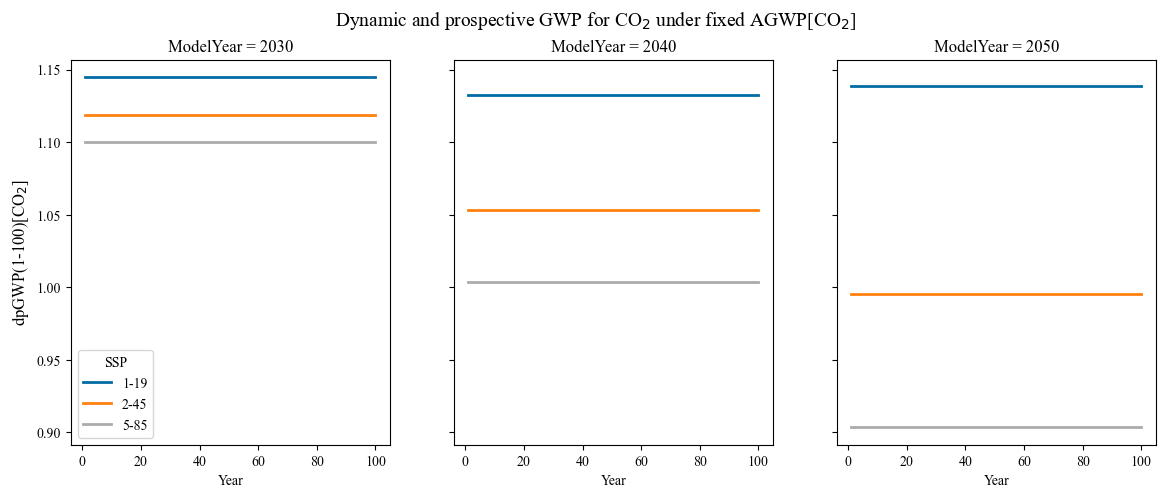

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CO2'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CO$_2$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CO$_2$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()


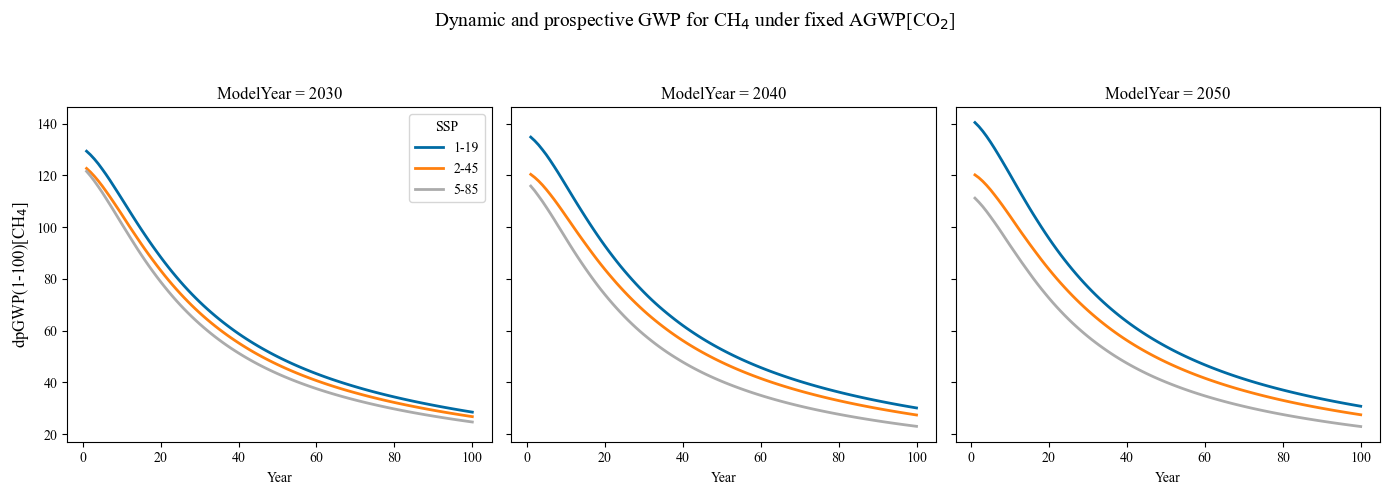

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CH4'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CH$_4$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CH$_4$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

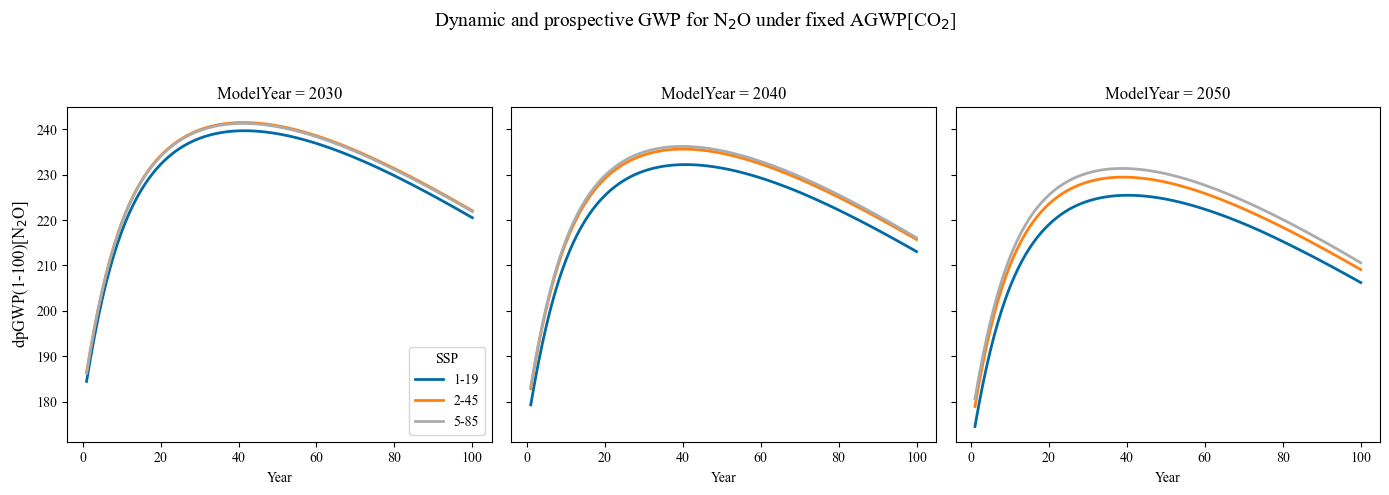

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['N2O'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[N$_2$O]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for N$_2$O under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### we'll combine the new GWP[CO2] (GWP[CO2]!= 1) with CH4/N2O in a new df and .nc 

In [11]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 0.0, 0.0, 0.0))  # CO2 no longer 1, all gas append 0 for y[0]
        for year in range(1, 101):
            co2 = gwp_results['CO2'][ssp][my][year - 1] # no longer = 1 as static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

# Step 2: Create DataFrame
df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP    ModelYear Year                                  
ssp119 2020      0     0.000000    0.000000    0.000000
                 1     1.194849  128.379377  188.574448
                 2     1.194849  126.706735  193.793514
                 3     1.194849  124.741411  198.625933
                 4     1.194849  122.601680  203.072652
...                         ...         ...         ...
ssp585 2050      96    0.903576   23.745009  212.594467
                 97    0.903576   23.541239  212.096970
                 98    0.903576   23.341118  211.597165
                 99    0.903576   23.145053  211.095159
                 100   0.903576   22.952932  210.591056

[1212 rows x 3 columns]

#### to later add to BW2-LCIA:: make sure SSP dim has the right name, no 'ssp' only 119, and MY dim has to be integer 

In [12]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 0.0, 0.0, 0.0))  # CO2 no longer 1, all gas append 0 for y[0]
        for year in range(1, 101):
            co2 = gwp_results['CO2'][ssp][my][year - 1] # no longer = 1 as static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
# to rename SSP column: 
df['SSP'] = df['SSP'].str.replace('ssp', '', regex=False)
# integer type for year columns
df['ModelYear'] = df['ModelYear'].astype(int)
df['Year'] = df['Year'].astype(int)

df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2020      0     0.000000    0.000000    0.000000
              1     1.194849  128.379377  188.574448
              2     1.194849  126.706735  193.793514
              3     1.194849  124.741411  198.625933
              4     1.194849  122.601680  203.072652
...                      ...         ...         ...
585 2050      96    0.903576   23.745009  212.594467
              97    0.903576   23.541239  212.096970
              98    0.903576   23.341118  211.597165
              99    0.903576   23.145053  211.095159
              100   0.903576   22.952932  210.591056

[1212 rows x 3 columns]

In [13]:
#Deleting rows with YEAR_index value 0
cf_df_filtered = df[~df.index.get_level_values("Year").isin([0])]
#cf_df_filtered
print(len(df), len(cf_df_filtered))

1212 1200


In [14]:
cf_xr = df.to_xarray() 
cf_xr2 = cf_df_filtered.to_xarray() 

In [15]:
cf_xr.to_netcdf('output_dpGWP_fixedCO2/CF_GWP0_100_perSSP_MY_majorghgs.nc')
cf_xr2.to_netcdf('output_dpGWP_fixedCO2/CF_GWP1_100_perSSP_MY_majorghgs.nc')

In [16]:
cf_xr2

<xarray.Dataset> Size: 30kB
Dimensions:    (SSP: 3, ModelYear: 4, Year: 100)
Coordinates:
  * SSP        (SSP) object 24B '119' '245' '585'
  * ModelYear  (ModelYear) int64 32B 2020 2030 2040 2050
  * Year       (Year) int64 800B 1 2 3 4 5 6 7 8 9 ... 93 94 95 96 97 98 99 100
Data variables:
    CO2_GWP    (SSP, ModelYear, Year) float64 10kB 1.195 1.195 ... 0.9036 0.9036
    CH4_GWP    (SSP, ModelYear, Year) float64 10kB 128.4 126.7 ... 23.15 22.95
    N2O_GWP    (SSP, ModelYear, Year) float64 10kB 188.6 193.8 ... 211.1 210.6